# Modelling On Datasets Beyond Bristol

After very high performance metrics were observed on experiments between the 2019 and 2025 snapshots on Bristol, it was considered that models may be overfitting. With 268 rows and roughly 400 features, the need for aggressive feature reduction had been previously clear, but even so, it was deemed beneficial to extend the dataset.

As such, the pipeline was ammended to have the capacity for fetching any local authority in England and the dataset was extended to include Sheffield, Exeter, Bournemouth, Christchurch and Poole, Plymouth and Newcastle. These cities were chosen due to their comparable size to Bristol and/or their geographic proximity with the idea that cities in the South-West may share some characteristics.

With this new dataset, modelling experiments can be repeated with the depth of rows that can give faith in high performance scores not stemming from overfitting.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from itertools import product

from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression

from xgboost import XGBRegressor

from scipy.stats import spearmanr




RANDOM_STATE = 19


: 

## Prepare Datasets

### Perform Loads and Joins

In [65]:
base_path = Path('.')  # current notebook directory

dfs = []

# Loop through folders at same level
for folder in base_path.iterdir():
    if folder.is_dir():
        
        # Loop through parquet files inside each folder
        for file in folder.glob("*.parquet"):
            df = pd.read_parquet(file)
            dfs.append(df)

features_df = pd.concat(dfs, ignore_index=True)

print(features_df.shape)

(1273, 434)


In [66]:
scores_2019 = pd.read_csv('imd_2019_scores.csv')
scores_2025 = pd.read_csv('imd_2025_scores.csv')

lsoa_lookup = pd.read_csv('lsoa_lookup.csv')

In [67]:
lsoa_lookup.head()

,lsoa_code_11,lsoa_name_11,lsoa_code_21,lsoa_name_21,change_indicator,lad_code,lad_name,ObjectId
0,E01031349,Adur 001A,E01031349,Adur 001A,U,E07000223,Adur,1
1,E01031350,Adur 001B,E01031350,Adur 001B,U,E07000223,Adur,2
2,E01031351,Adur 001C,E01031351,Adur 001C,U,E07000223,Adur,3
3,E01031352,Adur 001D,E01031352,Adur 001D,U,E07000223,Adur,4
4,E01031370,Adur 001E,E01031370,Adur 001E,U,E07000223,Adur,5


In [68]:
scores_2019.rename(columns={'LSOA code (2011)': 'lsoa_code_11',
                           'Index of Multiple Deprivation (IMD) Score': 'imd_score'
                          }, inplace=True)

# lsoa codes were changed in 2021, so 2019 codes are converted to 2021 codes using the lookup table
scores_2019 = scores_2019.merge(lsoa_lookup[['lsoa_code_11', 'lsoa_code_21']], on='lsoa_code_11', how='right')
scores_2019.drop(columns=['lsoa_code_11'], inplace=True)
scores_2019.rename(columns={'lsoa_code_21': 'lsoa_code'}, inplace=True)


scores_2025.rename(columns={'LSOA code (2021)': 'lsoa_code',
                           'Index of Multiple Deprivation (IMD) Score': 'imd_score'
                          }, inplace=True)

scores_2019 = scores_2019[['lsoa_code', 'imd_score']]
scores_2025 = scores_2025[['lsoa_code', 'imd_score']]

# Merge features and target datasets on 'lsoa_code'
data_2019 = pd.merge(features_df, scores_2025, on='lsoa_code')
data_2025 = pd.merge(features_df, scores_2025, on='lsoa_code', how='left')

In [69]:
print(data_2019.shape)
print(data_2025.shape)

(1273, 435)
(1273, 435)


### Clean Data 

In [70]:
# Ensure features are consistent between datasets
common_features = list(set(data_2019.columns).intersection(set(data_2025.columns)))
data_2019 = data_2019[common_features]
data_2025 = data_2025[common_features]

In [71]:
# Check that now datasets have the same shape
data_2019.shape == data_2025.shape   

True

#### Deal with Null, NaN and Inf

First infinite values are replaced with NaN

In [72]:
if np.isinf(data_2019.select_dtypes(include=['number'])).sum().sum()>0:
    print("Warning: Infinite values found in 2019 dataset, replaced with NaN.")
    data_2019.replace([np.inf, -np.inf], np.nan, inplace=True) 

if np.isinf(data_2025.select_dtypes(include=['number'])).sum().sum()>0:
    print("Warning: Infinite values found in 2025 dataset.")
    data_2025.replace([np.inf, -np.inf], np.nan, inplace=True)

Check missingness and drop features with >20% missing values, then impute remaining missing values with median

In [73]:
# 2019

missingness = data_2019.isna().sum().sort_values(ascending=False)
missingness_percent = (missingness / len(data_2019)) * 100
missingness_df_2019 = pd.DataFrame({
    'feature': missingness.index,
    'missing_count': missingness.values,
    'missing_percent': missingness_percent.values
})

data_2019 = data_2019.drop(columns=missingness_df_2019[missingness_df_2019['missing_percent'] > 20]['feature'])
data_2019 = data_2019.fillna(data_2019.median(numeric_only=True)) 

missingness_df_2019.sort_values('missing_percent', ascending=False).head(10)

,feature,missing_count,missing_percent
0,landuse_paddock_0,1195,93.872742
1,landuse_aquaculture_0,1195,93.872742
2,landuse_private_0,1109,87.117046
3,landuse_churchyard_0,1093,85.860173
4,landuse_basin_0,1093,85.860173
5,landuse_highway_0,1031,80.989788
6,landuse_terminal_0,1005,78.947368
7,landuse_storage_0,1005,78.947368
8,landuse_proposed_construction_0,930,73.055774
9,landuse_vineyard_0,930,73.055774


In [74]:
# 2025

missingness = data_2025.isna().sum().sort_values(ascending=False)
missingness_percent = (missingness / len(data_2025)) * 100
missingness_2025_df = pd.DataFrame({
    'feature': missingness.index,
    'missing_count': missingness.values,
    'missing_percent': missingness_percent.values
})

data_2025 = data_2025.drop(columns=missingness_2025_df[missingness_2025_df['missing_percent'] > 20]['feature'])
data_2025 = data_2025.fillna(data_2025.median(numeric_only=True)) 

missingness_2025_df.sort_values('missing_percent', ascending=False).head(10)

,feature,missing_count,missing_percent
0,landuse_paddock_0,1195,93.872742
1,landuse_aquaculture_0,1195,93.872742
2,landuse_private_0,1109,87.117046
3,landuse_churchyard_0,1093,85.860173
4,landuse_basin_0,1093,85.860173
5,landuse_highway_0,1031,80.989788
6,landuse_terminal_0,1005,78.947368
7,landuse_storage_0,1005,78.947368
8,landuse_proposed_construction_0,930,73.055774
9,landuse_vineyard_0,930,73.055774


In [75]:
# Ensure datasets still have the same shape after dropping features with high missingness
consistent_shape = data_2019.shape == data_2025.shape

print(f"Datasets have consistent shapes: {consistent_shape}")

if not consistent_shape:
    # redo the common features step to ensure both datasets have the same features after dropping those with high missingness
    common_features = list(set(data_2019.columns).intersection(set(data_2025.columns)))
    data_2019 = data_2019[common_features]
    data_2025 = data_2025[common_features]


Datasets have consistent shapes: True


In [76]:
data_2019.set_index("lsoa_code", inplace=True)
data_2025.set_index("lsoa_code", inplace=True)

X_2019 = data_2019.drop(columns=['imd_score'])
y_2019 = data_2019['imd_score']

X_2025 = data_2025.drop(columns=['imd_score'])
y_2025 = data_2025['imd_score']

## Exploratory Analysis

### Target Distribution

Start by observing dsitribution on scores.

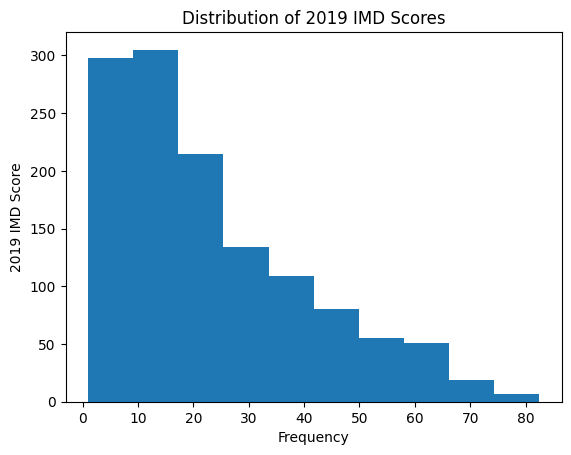

In [77]:
plt.figure()
plt.hist(y_2019, bins=10)
plt.ylabel("2019 IMD Score")
plt.xlabel("Frequency")
plt.title("Distribution of 2019 IMD Scores")
plt.show()

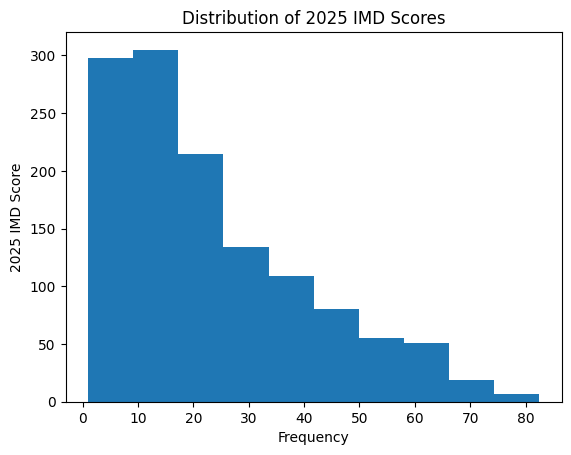

In [78]:
plt.figure()
plt.hist(y_2025, bins=10)
plt.ylabel("2025 IMD Score")
plt.xlabel("Frequency")
plt.title("Distribution of 2025 IMD Scores")
plt.show()

Though as noted, methodology changed between the two reports, scores seem to follow similar scale and distribution. For modeling, the postive skew is removed with a log transformation.

In [79]:
y_log_2019 = np.log1p(y_2019)
y_log_2025 = np.log1p(y_2025)

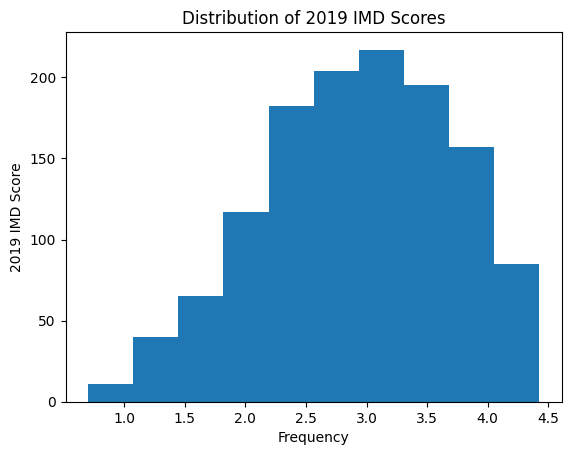

In [80]:
plt.figure()
plt.hist(y_log_2019, bins=10)
plt.ylabel("2019 IMD Score")
plt.xlabel("Frequency")
plt.title("Distribution of 2019 IMD Scores")
plt.show()

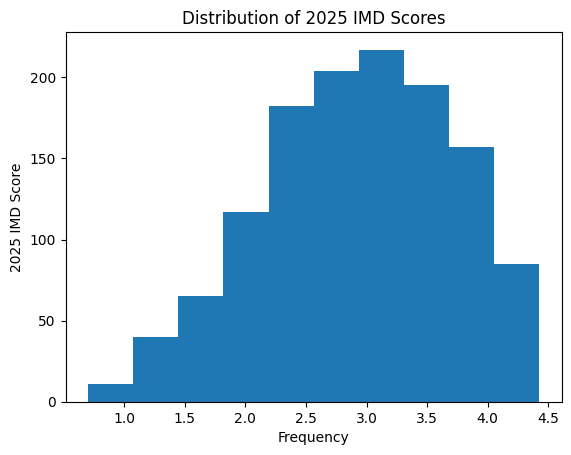

In [81]:
plt.figure()
plt.hist(y_log_2025, bins=10)
plt.ylabel("2025 IMD Score")
plt.xlabel("Frequency")
plt.title("Distribution of 2025 IMD Scores")
plt.show()

Similarity in distribution is now even more striking. To check train and validation splits will have some difference, correlation and scatter of scores is checked.

In [82]:
corr, p_value = pearsonr(y_log_2019, y_log_2025)
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 1.0
P-value: 0.0


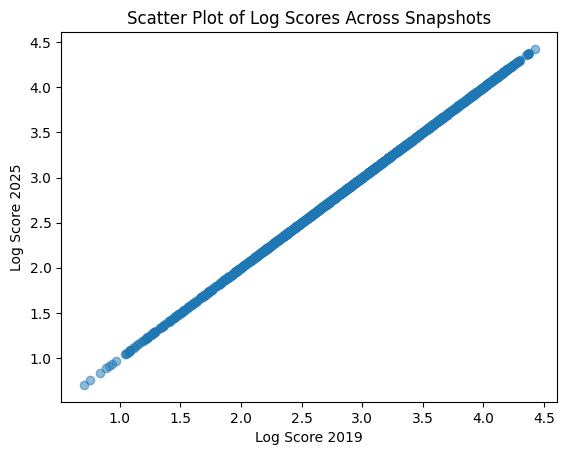

In [83]:
plt.scatter(y_log_2019, y_log_2025, alpha=0.5)
plt.xlabel("Log Score 2019")
plt.ylabel("Log Score 2025")
plt.title("Scatter Plot of Log Scores Across Snapshots")
plt.show()

### Feature Correlations

In [84]:
numeric_features_2019 = data_2019.select_dtypes(include=['number'])
numeric_features_2025 = data_2025.select_dtypes(include=['number'])

print(numeric_features_2019.corr().shape, numeric_features_2025.corr().shape) # these should be the same from previous cleaning steps
print("total number of correlations:", numeric_features_2019.size)



(411, 411) (411, 411)
total number of correlations: 523203


Due to large shape visualising as a full heatmap would be innefective. Instead correlation is checked through tables.

In [85]:

corr_with_target_2019 = numeric_features_2019.corr()["imd_score"].abs().sort_values(ascending=False)
corr_with_target_2025 = numeric_features_2025.corr()["imd_score"].abs().sort_values(ascending=False)

corr_with_target_2019 = corr_with_target_2019.drop("imd_score")
corr_with_target_2025 = corr_with_target_2025.drop("imd_score")

print("With target (2019):",end="\n\n")
print(corr_with_target_2019.head(10))
print("\nWith target (2025):",end="\n\n")
print(corr_with_target_2025.head(10))


With target (2019):

mean_monthly_nwr_claims       0.883805
total_nwr_claims              0.883805
total_claims                  0.882561
mean_monthly_claims           0.882561
total_prepfw_claims           0.823956
mean_monthly_prepfw_claims    0.823956
total_sfw_claims              0.751780
mean_monthly_sfw_claims       0.751780
mean_monthly_planfw_claims    0.732128
total_planfw_claims           0.732128
Name: imd_score, dtype: float64

With target (2025):

mean_monthly_nwr_claims       0.883805
total_nwr_claims              0.883805
total_claims                  0.882561
mean_monthly_claims           0.882561
total_prepfw_claims           0.823956
mean_monthly_prepfw_claims    0.823956
total_sfw_claims              0.751780
mean_monthly_sfw_claims       0.751780
mean_monthly_planfw_claims    0.732128
total_planfw_claims           0.732128
Name: imd_score, dtype: float64


Seeing that correlation on UC metrics are almost perfect, a scatterplot is produced. Note that since correlation was taken against the non-log transformed target, the standard target is used for the plot too.

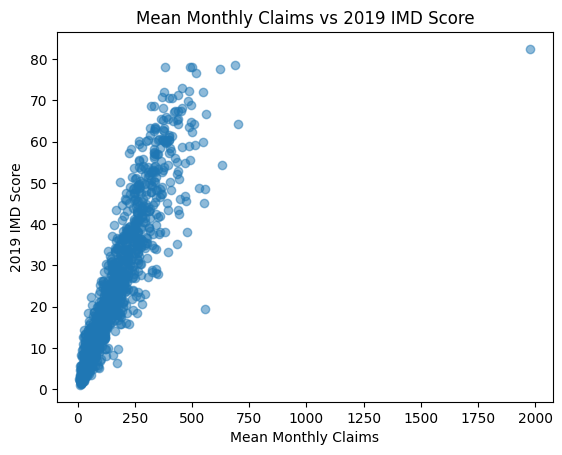

In [86]:
plt.scatter(data_2025[["mean_monthly_claims"]], y_2025, alpha=0.5)
plt.xlabel("Mean Monthly Claims")
plt.ylabel("2019 IMD Score")
plt.title("Mean Monthly Claims vs 2019 IMD Score")
plt.show()

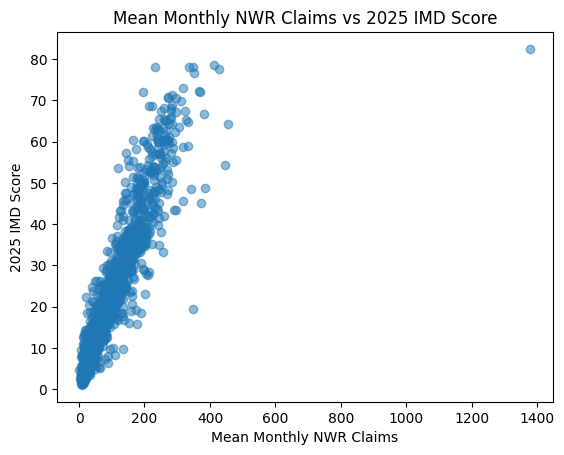

In [87]:
plt.scatter(data_2025[["mean_monthly_nwr_claims"]], y_2025, alpha=0.5)
plt.xlabel("Mean Monthly NWR Claims")
plt.ylabel("2025 IMD Score")  
plt.title("Mean Monthly NWR Claims vs 2025 IMD Score")
plt.show()

Seeing this, it is expected models should perform very well. Possibly to an extent which otherwise would appear to be overfitting. With a dataset of the shape p >> n, it was expected that the feature space would have to be reduced down by PCA, factor analysis or another method. On seeing these high correlations, it may even be sufficient to just select raw features using correlation scores. Regardless, both options will be explored. For PCA, correlations between features should be checked.

In [88]:
corr_2019 = numeric_features_2019.corr().abs()
corr_2025 = numeric_features_2025.corr().abs()

def corr_count(corr_matrix, threshold):
    count = corr_matrix[corr_matrix > threshold].count().sum() - len(corr_matrix)  # subtract self-correlations
    return count

count_2019 = corr_count(corr_2019, 0.8)
count_2025 = corr_count(corr_2025, 0.8)

print(f"Number of feature pairs with absolute correlation > 0.8 in 2019: {count_2019}")
print(f"As a percentage of total correlations: {count_2019 / numeric_features_2019.size:.2%}", end="\n\n")

print(f"Number of feature pairs with absolute correlation > 0.8 in 2025: {count_2025}")
print(f"As a percentage of total correlations: {count_2025 / numeric_features_2025.size:.2%}")


Number of feature pairs with absolute correlation > 0.8 in 2019: 5098
As a percentage of total correlations: 0.97%

Number of feature pairs with absolute correlation > 0.8 in 2025: 5098
As a percentage of total correlations: 0.97%


Observing about a third of absoloute correlations in the feature space for both snapshots is over 0.8, analysis is repeated on a threshold of 0.5

In [89]:
count_2019 = corr_count(corr_2019, 0.5)
count_2025 = corr_count(corr_2025, 0.5)

print(f"Number of feature pairs with absolute correlation > 0.5 in 2019: {count_2019}")
print(f"As a percentage of total correlations: {count_2019 / numeric_features_2019.size:.2%}", end="\n\n")

print(f"Number of feature pairs with absolute correlation > 0.5 in 2025: {count_2025}")
print(f"As a percentage of total correlations: {count_2025 / numeric_features_2025.size:.2%}")

Number of feature pairs with absolute correlation > 0.5 in 2019: 31572
As a percentage of total correlations: 6.03%

Number of feature pairs with absolute correlation > 0.5 in 2025: 31572
As a percentage of total correlations: 6.03%


With this, about 60% of correlations are found to be of some importance.

These measures indicate high multicolinearity. While this may be less of an issue for tree-based models, regression models will be unstable. To accomodate for this, PCA will be used since it produces orthogonal features.

### Feature Reduction

In [91]:
scaler = StandardScaler()
X_scaled_2019 = scaler.fit_transform(X_2019)
X_scaled_2025 = scaler.fit_transform(X_2025)

Number of components 95% (2019): 106


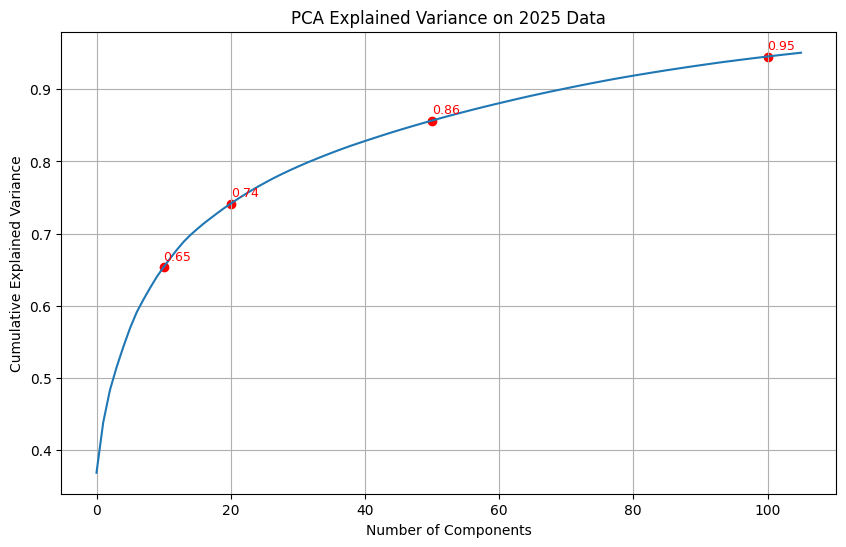

In [93]:
components_to_try = [100, 50, 20, 10]


pca_pct_95 = PCA(n_components=0.95)  # keep 95% variance
X_pca_pct_95_2019 = pca_pct_95.fit_transform(X_scaled_2019)
print("Number of components 95% (2019):", pca_pct_95.n_components_)

cum_var = np.cumsum(pca_pct_95.explained_variance_ratio_)

plt.figure(figsize=(10,6))
plt.plot(cum_var)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance on 2025 Data")
plt.grid(True)

# Annotate specific component points
for c in components_to_try:
    if c <= len(cum_var):  # avoid index error
        plt.scatter(c, cum_var[c], color='red')  # -1 because Python indexing
        plt.text(c, cum_var[c]+0.01, f"{cum_var[c]:.2f}", color='red', fontsize=9)

## Modelling

## Evaluation

In [ ]:
results = []

# feature reduction methods
reduction_params = {
    'none': [None],  
    'pca': [5, 10, 20, 50, 100],
    'fa': [5, 10, 20, 50, 100],
    'kbest': [5, 10, 20, 50, 100]
}

# models and parameter grids
models = {
    'ridge': (
        Ridge(random_state=RANDOM_STATE),
        {'model__alpha': [0.01, 0.1, 1, 10, 100]}
    ),
    'lasso': (
        Lasso(random_state=RANDOM_STATE, max_iter=10000),
        {'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
    ),
    'rf': (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {
            'model__n_estimators': [100, 200, 500],
            'model__max_depth': [None, 5, 10, 20],
            'model__min_samples_split': [2, 5, 10],
            'model__max_features': ['sqrt', 'log2']
        }
    ),
    'extra_trees': (
        ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {
            'model__n_estimators': [100, 200, 500],
            'model__max_depth': [None, 5, 10, 20],
            'model__min_samples_split': [2, 5, 10],
            'model__max_features': ['sqrt', 'log2']
        }
    ),
    'gboost': (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {
            'model__n_estimators': [100, 200],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__max_depth': [3, 5, 7]
        }
    ),
    'xgb': (
        XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
        {
            'model__n_estimators': [100, 200],
            'model__learning_rate': [0.01, 0.1],
            'model__max_depth': [3, 6, 10],
            'model__subsample': [0.7, 1.0]
        }
    )
}


In [ ]:

# Create all combinations upfront
all_configs = list(product(
    reduction_params.items(),
    models.items()
))

total_steps = sum(len(params) for _, params in reduction_params.items()) * len(models)

pbar = tqdm(total=total_steps)

results = []

for reducer_name, components_list in reduction_params.items():
    for n_components in components_list:

        # Define reducer
        if reducer_name == 'pca':
            reducer = PCA(n_components=n_components)
        elif reducer_name == 'fa':
            reducer = FactorAnalysis(n_components=n_components)
        elif reducer_name == 'kbest':
            reducer = SelectKBest(f_regression, k=n_components)
        else:
            reducer = 'passthrough'

        for model_name, (model, param_dist) in models.items():

            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('reduce', reducer),
                ('model', model)
            ])

            search = RandomizedSearchCV(
                pipe,
                param_distributions=param_dist,
                n_iter=10,
                scoring='r2',
                cv=5,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )

            search.fit(X_2019, y_log_2019)

            best_model = search.best_estimator_
            best_cv_score = search.best_score_

            y_pred = best_model.predict(X_2025)
            spearman_rank, p = spearmanr(y_log_2025, y_pred)

            results.append({
                'model': model_name,
                'reduction': reducer_name,
                'reduction_param': n_components,
                'best_cv_r2': best_cv_score,
                'val_spearman': spearman_rank,
                'p_value': p,
                'best_params': search.best_params_
            })

            pbar.update(1)

pbar.close()

results_df = pd.DataFrame(results)

  0%|          | 0/96 [00:00<?, ?it/s]c:\Users\Python -test-\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
  1%|          | 1/96 [00:09<14:50,  9.37s/it]c:\Users\Python -test-\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
  5%|▌         | 5/96 [03:28<1:40:44, 66.42s/it]

KeyboardInterrupt: 